# Iterative Imputation (MICE)

## What is Iterative Imputation?

Iterative Imputation is an advanced missing value imputation technique that predicts missing values by using the other available features in the dataset. Instead of replacing missing values with a constant statistic (such as mean or median), it builds a machine learning model to estimate the missing values.

It is also known as **MICE (Multiple Imputation by Chained Equations)**.

---

## Why Do We Use Iterative Imputation?

Simple imputation techniques like Mean, Median, and Mode ignore the relationship between features. This may reduce the quality of the dataset.

Iterative Imputation utilizes the relationships among features to generate more accurate estimates for missing values.

For example, in the Titanic dataset, the missing values in the **Age** column can be estimated using features like:

- Passenger Class (Pclass)
- Fare
- Number of Siblings/Spouses (SibSp)
- Number of Parents/Children (Parch)

Since these features are related to Age, the predicted values are generally more realistic than simply using the mean or median.

---

## How Does Iterative Imputation Work?

The algorithm follows these steps:

1. Replace all missing values with initial estimates (usually the mean).
2. Select one feature that contains missing values.
3. Treat this feature as the target variable.
4. Use the remaining features as input variables.
5. Train a machine learning model to predict the missing values.
6. Replace the missing values with the predicted values.
7. Repeat the process for every feature containing missing values.
8. Continue iterating until the imputed values stabilize or the maximum number of iterations is reached.

---

## Advantages

- Produces more accurate imputations than Mean or Median Imputation.
- Preserves relationships between variables.
- Suitable for numerical datasets.
- Reduces bias introduced by simple imputation methods.
- Useful when multiple features contain missing values.

---

## Disadvantages

- Computationally expensive.
- Slower than simple imputation techniques.
- Performance depends on the predictive relationship between features.
- More difficult to interpret compared to Mean or Median Imputation.

---

## When Should We Use Iterative Imputation?

Use Iterative Imputation when:

- Multiple numerical features have missing values.
- Features are correlated with each other.
- Higher prediction accuracy is required.
- Dataset size is moderate to large.

---

## When Should We Avoid It?

Avoid using Iterative Imputation when:

- Features have little or no relationship.
- The dataset is extremely large and computation time is critical.
- Most columns are categorical.
- A quick baseline model is sufficient.

---

## Real-World Example

Suppose an employee database has missing values in the **Salary** column.

Instead of filling the missing salaries with the average salary, Iterative Imputation predicts them using information such as:

- Age
- Experience
- Education
- Job Role
- Department

This generally produces more realistic salary estimates.

---

## Scikit-learn Class

```python
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
```

---

## Key Parameters

- **max_iter** → Maximum number of iterations.
- **random_state** → Ensures reproducible results.
- **initial_strategy** → Strategy used for the initial imputation (default is mean).
- **estimator** → Machine learning model used for prediction (default: Bayesian Ridge Regression).

---

## Summary

Iterative Imputation is an advanced missing value handling technique that estimates missing values by repeatedly training machine learning models using the remaining features. Because it considers the relationships among variables, it often provides better imputations than simple statistical methods such as Mean, Median, or Mode Imputation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df = df[['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']]

In [9]:
df.head()

,Age,Fare,Pclass,SibSp,Parch
0,22.0,7.2500,3,1,0
1,38.0,71.2833,1,1,0
2,26.0,7.9250,3,0,0
3,35.0,53.1000,1,1,0
4,35.0,8.0500,3,0,0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [11]:
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (712, 5)
Testing Data Shape  : (179, 5)


In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [13]:
imputer = IterativeImputer(random_state=42)

In [14]:
imputer.get_params()

{'add_indicator': False,
 'estimator': None,
 'fill_value': None,
 'imputation_order': 'ascending',
 'initial_strategy': 'mean',
 'keep_empty_features': False,
 'max_iter': 10,
 'max_value': inf,
 'min_value': -inf,
 'missing_values': nan,
 'n_nearest_features': None,
 'random_state': 42,
 'sample_posterior': False,
 'skip_complete': False,
 'tol': 0.001,
 'verbose': 0}

In [15]:
imputer.fit(X_train)

IterativeImputer(random_state=42)

In [16]:
X_train_trf = imputer.transform(X_train)
X_test_trf = imputer.transform(X_test)

In [17]:
X_train_trf = pd.DataFrame(
    X_train_trf,
    columns=X_train.columns
)

X_test_trf = pd.DataFrame(
    X_test_trf,
    columns=X_test.columns
)

In [18]:
X_train_trf.isnull().sum()

,0
Age,0
Fare,0
Pclass,0
SibSp,0
Parch,0


In [19]:
X_test_trf.isnull().sum()

,0
Age,0
Fare,0
Pclass,0
SibSp,0
Parch,0


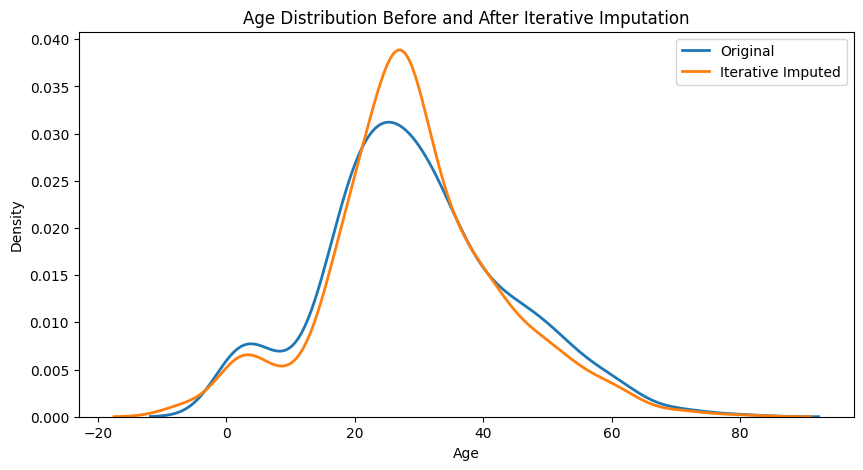

In [20]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    X_train['Age'],
    label='Original',
    linewidth=2
)

sns.kdeplot(
    X_train_trf['Age'],
    label='Iterative Imputed',
    linewidth=2
)

plt.legend()
plt.title("Age Distribution Before and After Iterative Imputation")
plt.show()

In [21]:
print("Original Mean :", X_train['Age'].mean())
print("Imputed Mean  :", X_train_trf['Age'].mean())

print()

print("Original Std :", X_train['Age'].std())
print("Imputed Std  :", X_train_trf['Age'].std())

Original Mean : 29.498846153846156
Imputed Mean  : 29.052997382975192

Original Std : 14.500058870492348
Imputed Std  : 13.68379752739875


In [22]:
X_train_trf.head()

,Age,Fare,Pclass,SibSp,Parch
0,45.5,28.5000,1.0,0.0,0.0
1,23.0,13.0000,2.0,0.0,0.0
2,32.0,7.9250,3.0,0.0,0.0
3,26.0,7.8542,3.0,1.0,0.0
4,6.0,31.2750,3.0,4.0,2.0
